<a href="https://colab.research.google.com/github/marwaashfaq2004-ai/ANN-BLOOD-CELL-CLASSIFICATION-PROJECT/blob/main/ANN_PROJECT(AneRBC).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Task 1.1 — Install & Imports
!pip install -q seaborn
import os, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
warnings.filterwarnings('ignore')
# Seed for reproducibility
SEED = 42
def set_seed(s=42):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
set_seed()
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES     = ['basophil','eosinophil','erythroblast','ig',
               'lymphocyte','monocyte','neutrophil','platelet']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224
BATCH_SIZE  = 32
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
print(f' Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f' GPU: {torch.cuda.get_device_name(0)}')
print(' All imports done!')


 Device: cuda
 GPU: Tesla T4
 All imports done!


In [4]:
# Task 1.1 — Mount Google Drive & Extract Dataset
from google.colab import drive
drive.mount('/content/drive')
#   Change this path if your zip is in a subfolder
ZIP_PATH = '/content/drive/MyDrive/archive.zip'
RAW_DIR  = '/content/data/bloodcells_dataset'
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)
if not os.path.exists(RAW_DIR):
    print(' Extracting dataset...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)
    print(' Extraction done!')
else:
    print(' Dataset already extracted.')
for cls in CLASSES:
    n = len(list(Path(f'{RAW_DIR}/{cls}').glob('*.jpg')))
    print(f'  {cls:20s}: {n} images')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Extracting dataset...
 Extraction done!
  basophil            : 1218 images
  eosinophil          : 3117 images
  erythroblast        : 1551 images
  ig                  : 2895 images
  lymphocyte          : 1214 images
  monocyte            : 1420 images
  neutrophil          : 3329 images
  platelet            : 2348 images


 Total valid images : 17092
 Corrupted (removed): 0


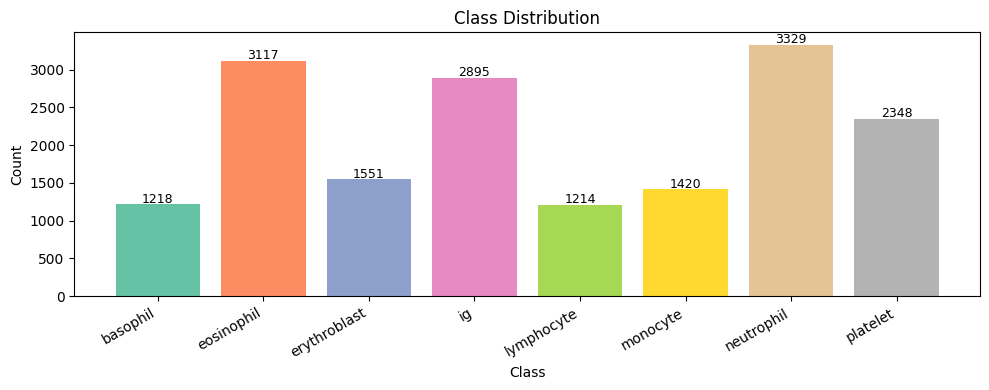

label
basophil        1218
eosinophil      3117
erythroblast    1551
ig              2895
lymphocyte      1214
monocyte        1420
neutrophil      3329
platelet        2348
Name: count, dtype: int64


In [5]:
# Task 1.2 — Check corrupted images + class distribution
records = []
bad     = []
for cls in CLASSES:
    for p in Path(f'{RAW_DIR}/{cls}').glob('*'):
        if p.suffix.lower() not in ('.jpg','.jpeg','.png'): continue
        try:
            with Image.open(p) as img: img.verify()
            records.append({'path': str(p), 'label': cls})
        except:
            bad.append(str(p))
print(f' Total valid images : {len(records)}')
print(f' Corrupted (removed): {len(bad)}')
for p in bad: os.remove(p)
df_all = pd.DataFrame(records)
# Class distribution bar chart
dist = df_all['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10,4))
colors = plt.cm.Set2(np.linspace(0,1,len(dist)))
bars = ax.bar(dist.index, dist.values, color=colors)
for b,v in zip(bars, dist.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
            str(v), ha='center', fontsize=9)
ax.set_title('Class Distribution'); ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()
print(dist)


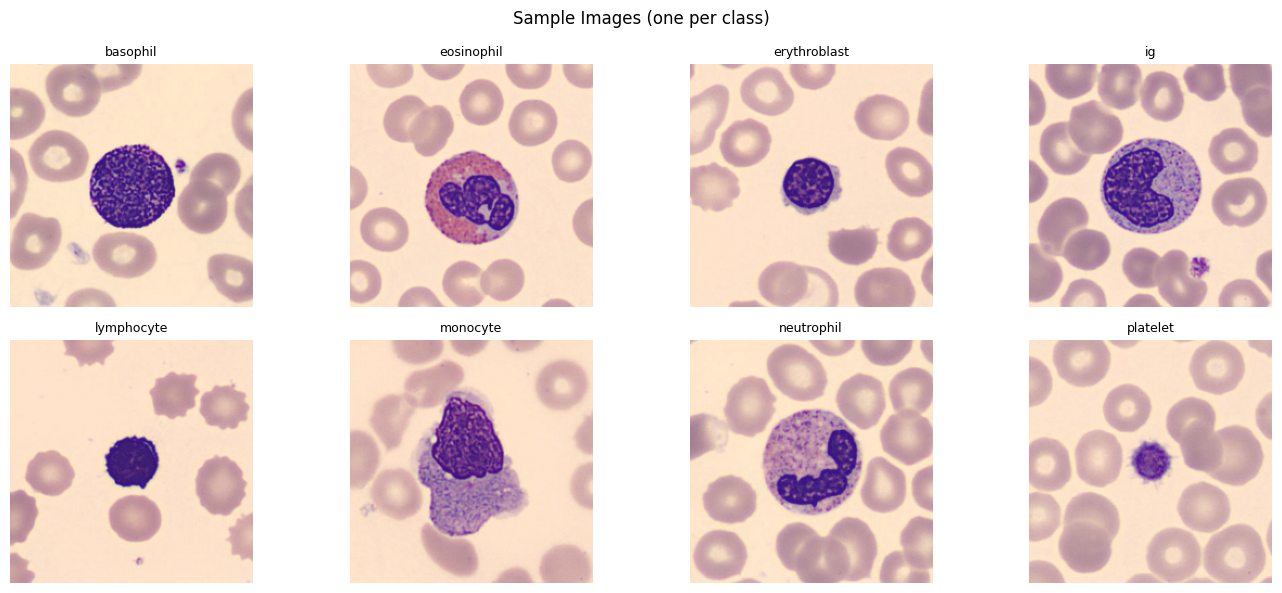

 Transforms ready!


In [6]:
# Task 1.3 — Transforms: resize, normalize, augment
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
# Show one sample per class
fig, axes = plt.subplots(2, 4, figsize=(14,6))
fig.suptitle('Sample Images (one per class)')
for ax, cls in zip(axes.flat, CLASSES):
    p = df_all[df_all['label']==cls].iloc[0]['path']
    ax.imshow(Image.open(p).convert('RGB').resize((224,224)))
    ax.set_title(cls, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()
print(' Transforms ready!')


In [7]:
# Task 1.4 — Stratified 70/15/15 split
class BloodCellDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.c2i = {c:i for i,c in enumerate(CLASSES)}
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        r   = self.df.iloc[idx]
        img = Image.open(r['path']).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, self.c2i[r['label']]
df_tr, df_tmp = train_test_split(
    df_all, test_size=0.30, stratify=df_all['label'], random_state=SEED)
df_val, df_te = train_test_split(
    df_tmp, test_size=0.50, stratify=df_tmp['label'], random_state=SEED)
print(f'Train:{len(df_tr)}  Val:{len(df_val)}  Test:{len(df_te)}')
train_ds = BloodCellDataset(df_tr,  train_transforms)
val_ds   = BloodCellDataset(df_val, val_test_transforms)
test_ds  = BloodCellDataset(df_te,  val_test_transforms)
# Weighted sampler for class imbalance
lc  = df_tr['label'].value_counts().sort_index()
cw  = 1.0 / torch.tensor([lc[c] for c in CLASSES], dtype=torch.float)
sw  = torch.tensor([cw[CLASSES.index(r)] for r in df_tr['label']])
sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
print(f' Loaders ready  Train:{len(train_loader)}  Val:{len(val_loader)}  Test:{len(test_loader)}')


Train:11964  Val:2564  Test:2564
 Loaders ready  Train:374  Val:81  Test:81


---
#  Task 2 — Custom CNNs (3 / 4 / 5 layers)